# Grouped CIFSC & ETF data

In [20]:
### Import CSV that is produced in the ETF_Creation Notebook that is called results
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check if the file exists
GroupedCIFSC_ETF = pd.read_csv('result.csv')
GroupedCIFSC_ETF.head() 


,Month Number,ConsolidatedCIFSC,total_net_assets,total_gross_sales,total_redemptions,normalized_value,Ticker,Close,CloseNormalized,PercentMonthlyChange
0,1,Money Market,2.680732e+10,1.884896e+09,1.729899e+09,1.000000,BIL,76.786507,1.000000,NaN
1,2,Money Market,2.683140e+10,1.917092e+09,1.668301e+09,1.000898,BIL,76.786507,1.000000,0.000000
2,4,Money Market,2.558672e+10,1.507053e+09,2.018058e+09,0.954467,BIL,76.820122,1.000438,0.000438
3,5,Money Market,2.576768e+10,1.961290e+09,1.627424e+09,0.961218,BIL,76.820122,1.000438,0.000000
4,6,Money Market,2.538923e+10,1.678538e+09,1.937030e+09,0.947101,BIL,76.803307,1.000219,-0.000219


In [32]:
GroupedCIFSC_ETF["NetSales"] = GroupedCIFSC_ETF['total_gross_sales'] - GroupedCIFSC_ETF['total_redemptions']
# Filter rows where 'Month Number' equals 1
initial_net_asset = GroupedCIFSC_ETF[GroupedCIFSC_ETF['Month Number'] == 1].set_index('ConsolidatedCIFSC')['total_net_assets']

# Map the initial 'total_net_asset' back to the main DataFrame
GroupedCIFSC_ETF['Initial_Net_Asset'] = GroupedCIFSC_ETF['ConsolidatedCIFSC'].map(initial_net_asset)
GroupedCIFSC_ETF.head()
GroupedCIFSC_ETF["Cumulative_Net_Sales"] = (GroupedCIFSC_ETF.groupby('ConsolidatedCIFSC')['NetSales'].cumsum()/GroupedCIFSC_ETF['Initial_Net_Asset'])+1

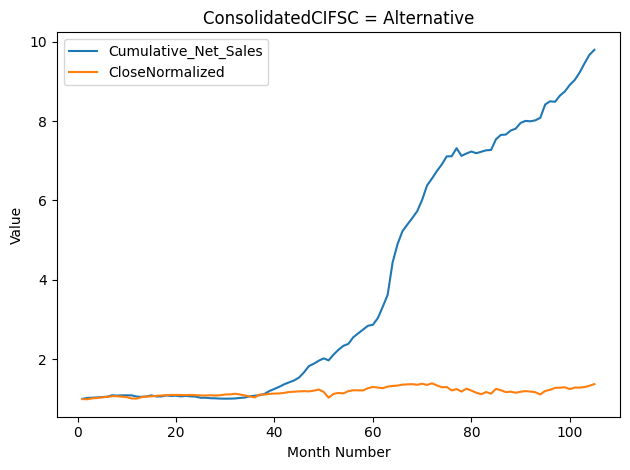

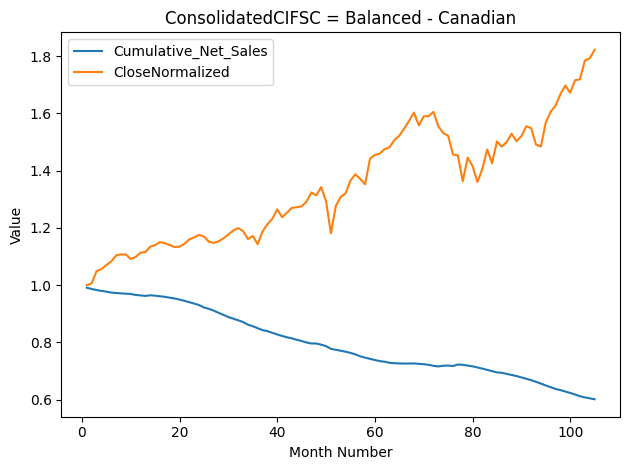

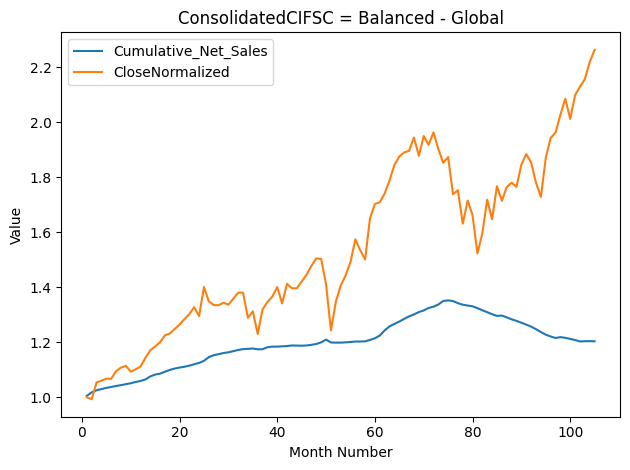

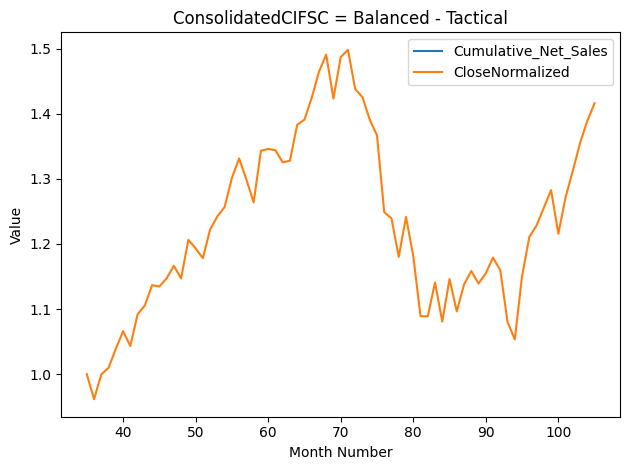

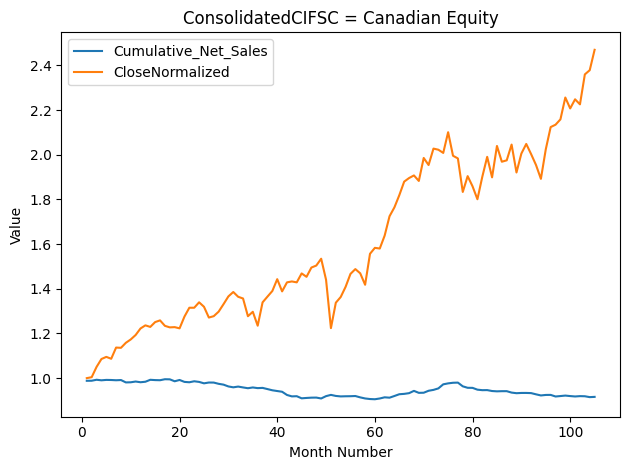

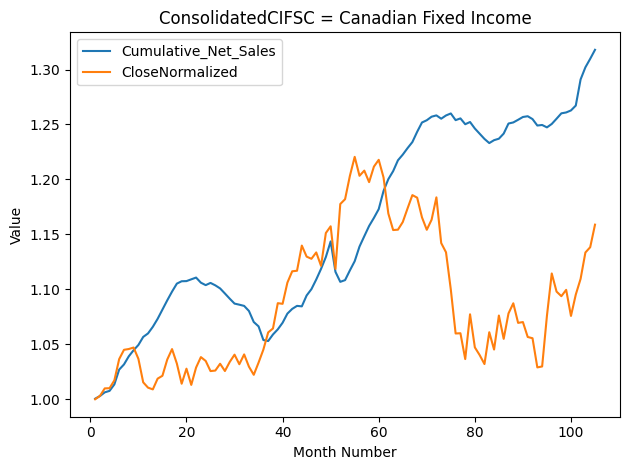

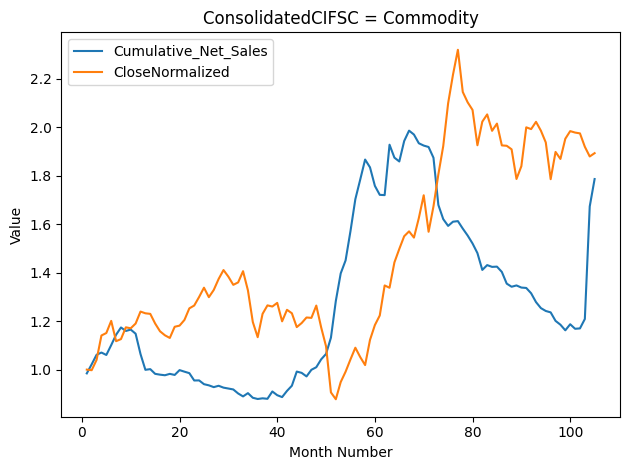

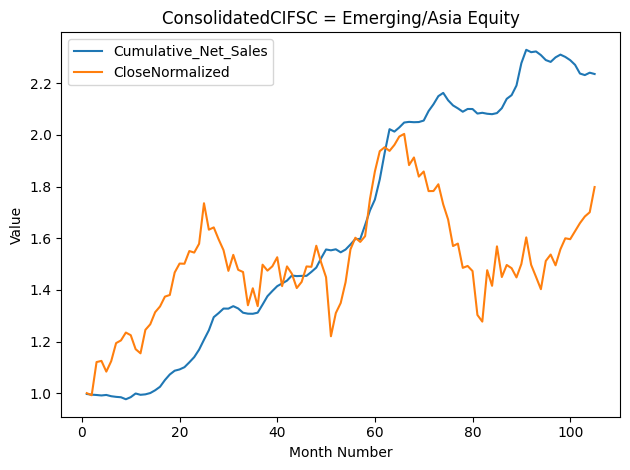

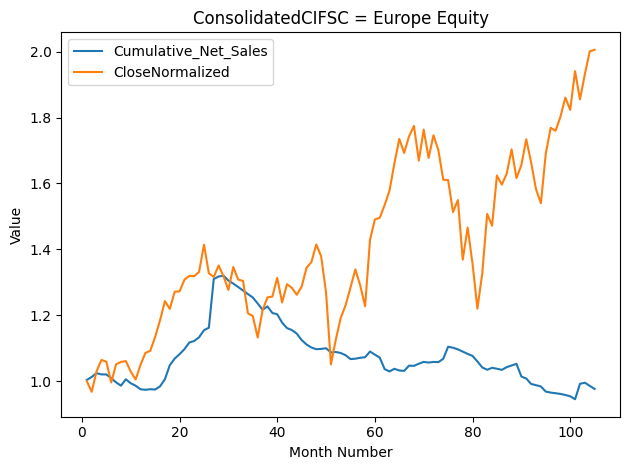

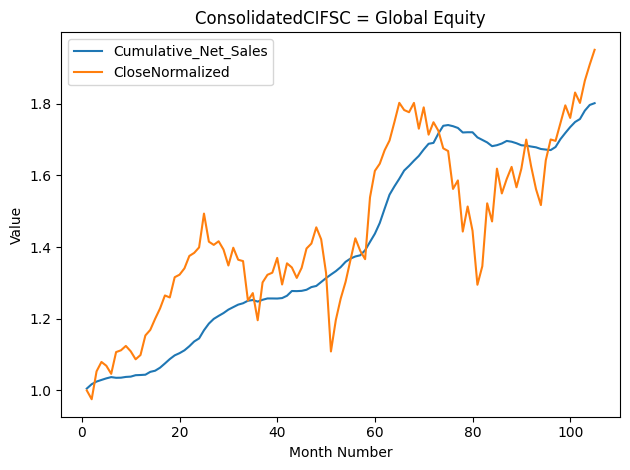

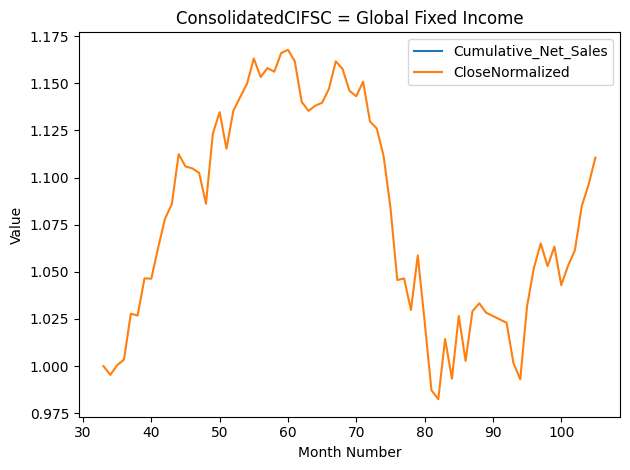

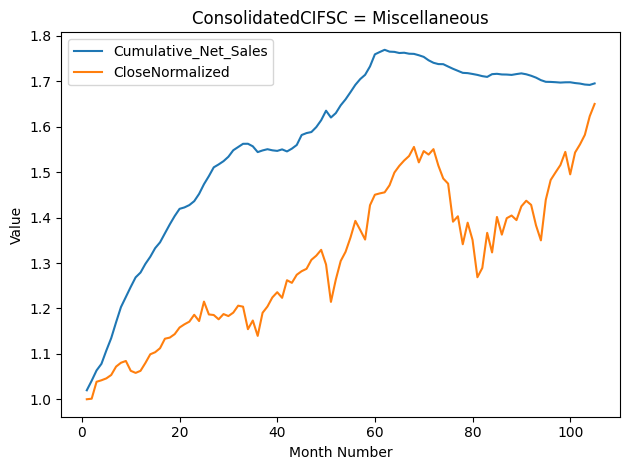

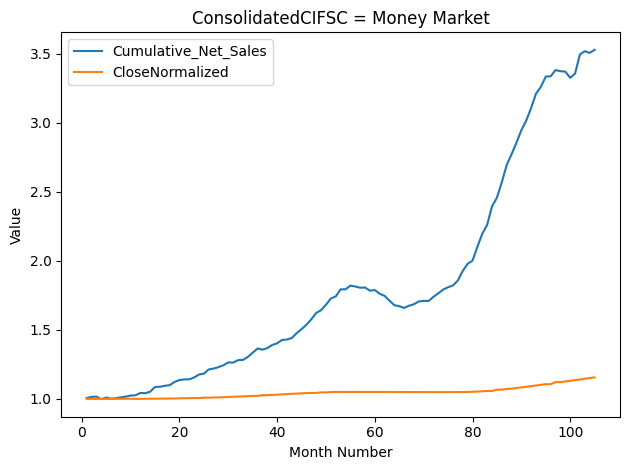

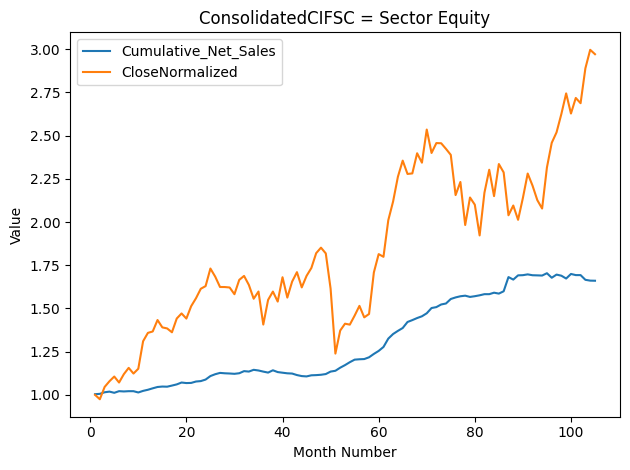

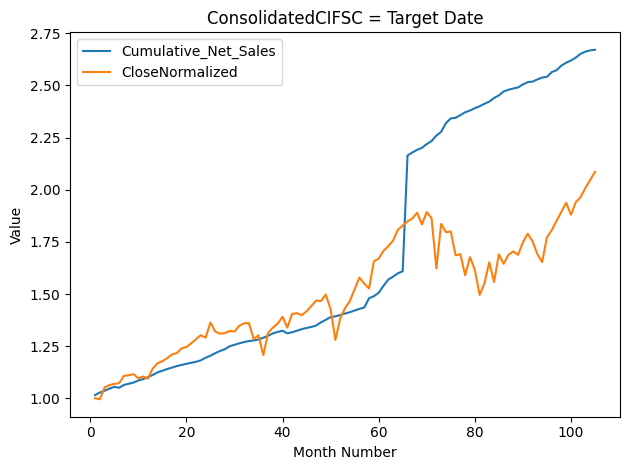

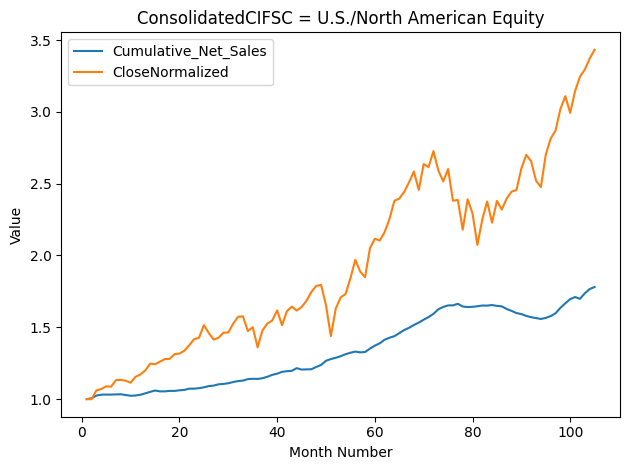

In [33]:

 
# assume your DataFrame is named df

# if Month Number isn’t already numeric or datetime, convert it:

# df['Month Number'] = pd.to_numeric(df['Month Number'])
 
# make sure it’s sorted so the lines don’t jump around

GroupedCIFSC_ETF = GroupedCIFSC_ETF.sort_values(['ConsolidatedCIFSC','Month Number'])
 
for name, grp in GroupedCIFSC_ETF.groupby('ConsolidatedCIFSC'):

    plt.figure()

    plt.plot(grp['Month Number'], grp['Cumulative_Net_Sales'],    label='Cumulative_Net_Sales')

    plt.plot(grp['Month Number'], grp['CloseNormalized'],      label='CloseNormalized')

    plt.title(f'ConsolidatedCIFSC = {name}')

    plt.xlabel('Month Number')

    plt.ylabel('Value')

    plt.legend()

    plt.tight_layout()

    plt.show()

 